In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
df  = pd.read_csv('/content/train.csv')

In [4]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


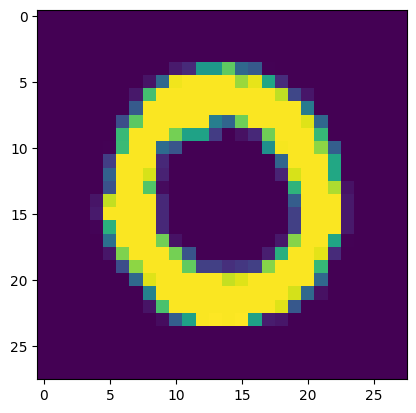

In [5]:
plt.imshow(df.iloc[1,1:].values.reshape(28,28))

In [60]:
X = df.drop(columns='label')
X = X/255
y = df['label']
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)

In [61]:
X.shape

(42000, 784)

In [62]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(148,activation='relu',input_dim=784))
model.add(Dense(10,activation='softmax'))
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 148)            │       116,180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,670 (459.65 KB)

 Trainable params: 117,670 (459.65 KB)

 Non-trainable params: 0 (0.00 B)

None


In [63]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [64]:
history = model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8964 - loss: 0.3548 - val_accuracy: 0.9375 - val_loss: 0.2237
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9502 - loss: 0.1644 - val_accuracy: 0.9565 - val_loss: 0.1481
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9684 - loss: 0.1115 - val_accuracy: 0.9625 - val_loss: 0.1293
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9760 - loss: 0.0832 - val_accuracy: 0.9613 - val_loss: 0.1283
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9815 - loss: 0.0627 - val_accuracy: 0.9694 - val_loss: 0.1096
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9869 - loss: 0.0474 - val_accuracy: 0.9690 - val_loss: 0.1054
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9910 - loss: 0.0354 - val_accuracy: 0.9714 - val_loss: 0.1044
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9932 - loss: 0.0269 - val_accuracy: 0.

In [65]:
y_pred = model.predict(X_test)

329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [66]:
y_pred = y_pred.argmax(axis=1)

In [67]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9644761904761905

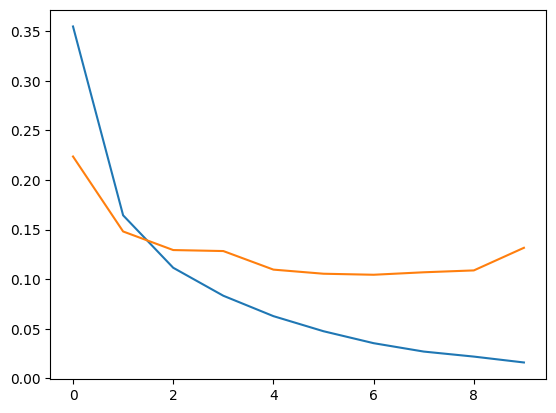

In [68]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

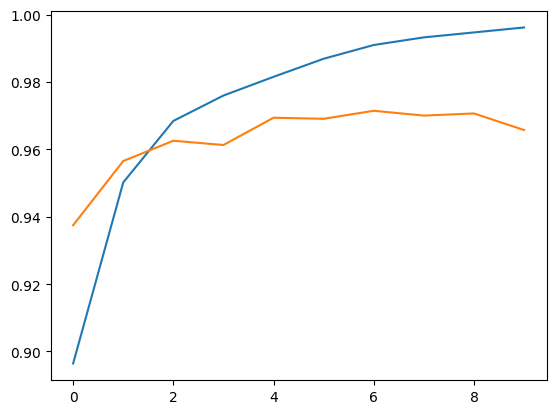

In [69]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

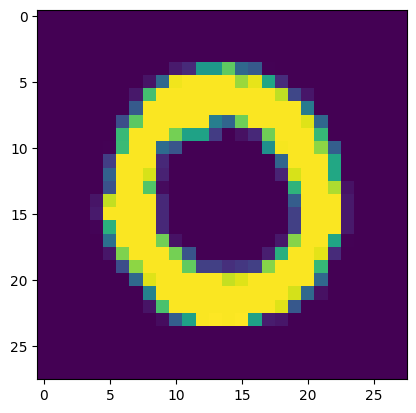

In [70]:
plt.imshow(X.iloc[1].values.reshape(28,28))

In [71]:
model.predict(X.iloc[1].values.reshape(1,784)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([0])